## Analisis de taxis del Aeropuerto Internacional O'Hare de Chicago,il.

In [2]:
#importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from scipy import stats

# Cargamos los archivos CSV
trips = pd.read_csv('moved_project_sql_result_01.csv')
dropoff = pd.read_csv('moved_project_sql_result_04.csv')
wheather_cond = pd.read_csv('moved_project_sql_result_07.csv')


**Viajes por Compañia**

In [3]:
# Se imprime la información de los viajes por compañia y se realiza limpieza de datos
trips.info()
trips['trips_amount'] = pd.to_numeric(trips['trips_amount'], errors='coerce')

#muestra los valores duplicados y nulos
print('Valores duplicados en viajes por compañía:')
print(trips.duplicated().sum())
print('Valores nulos en viajes por compañía:')
print(trips.isnull().sum())

#muestra las primeras filas del dataframe de viajes
display(trips.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
Valores duplicados en viajes por compañía:
0
Valores nulos en viajes por compañía:
company_name    0
trips_amount    0
dtype: int64


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


**Viajes por Barrio**

In [4]:
# Se imprime la información de los viajes por barrio y se realiza limpieza de datos
dropoff.info()
dropoff['average_trips'] = pd.to_numeric(dropoff['average_trips'], errors='coerce')

#muestra los valores duplicados y nulos
print('Valores duplicados en viajes por barrio:')   
print(dropoff.duplicated().sum())
print('Valores nulos en viajes por barrio:')
print(dropoff.isnull().sum())

# muestra las primeras filas del dataframe de viajes por barrio
display(dropoff.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
Valores duplicados en viajes por barrio:
0
Valores nulos en viajes por barrio:
dropoff_location_name    0
average_trips            0
dtype: int64


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


## Paso 4

Top 10 barrios por finalización de viajes:


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


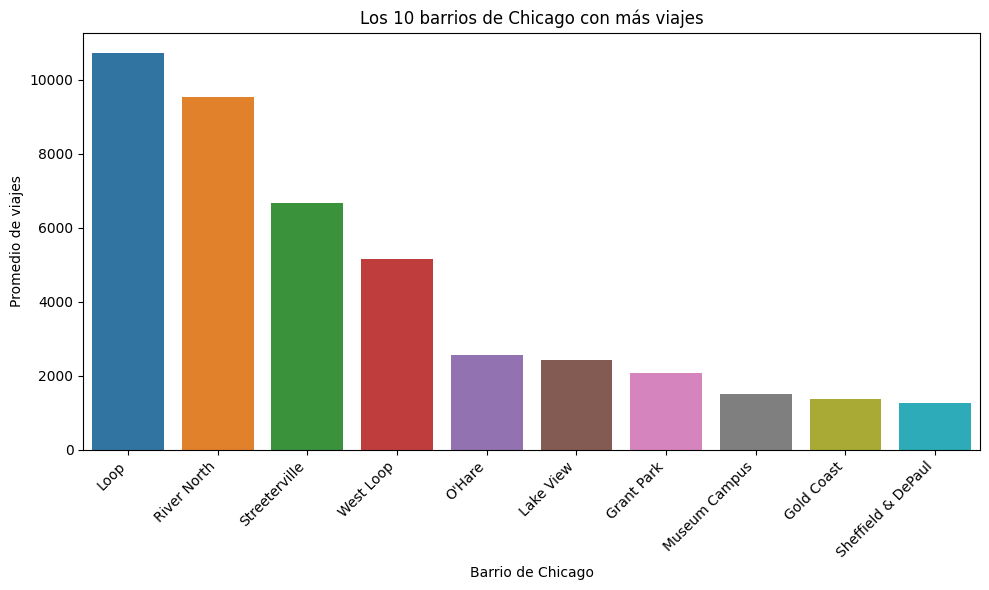

In [5]:
# Identificar los 10 principales barrios por finalización de viajes
top10_barrios = dropoff.sort_values('average_trips', ascending=False).head(10).reset_index(drop=True)    
print('Top 10 barrios por finalización de viajes:')
display(top10_barrios)

# Gráfico: 10 barrios principales por número de finalizaciones
plt.figure(figsize=(10,6))
sns.barplot(data=top10_barrios, x='dropoff_location_name', y='average_trips')
plt.xticks(rotation=45, ha='right')
plt.title('Los 10 barrios de Chicago con más viajes')
plt.xlabel('Barrio de Chicago')
plt.ylabel('Promedio de viajes')
plt.tight_layout()
plt.show()


**Gráfico de los 10 barrios principales por finalización de viajes:**

Los barrios Loop, River North y Streeterville son los que más viajes finalizados registran, lo que sugiere que son zonas de alta actividad, probablemente por su importancia comercial, turística y de negocios. El alto promedio de viajes en estos barrios puede estar relacionado con la densidad de población, atracciones y centros de trabajo.


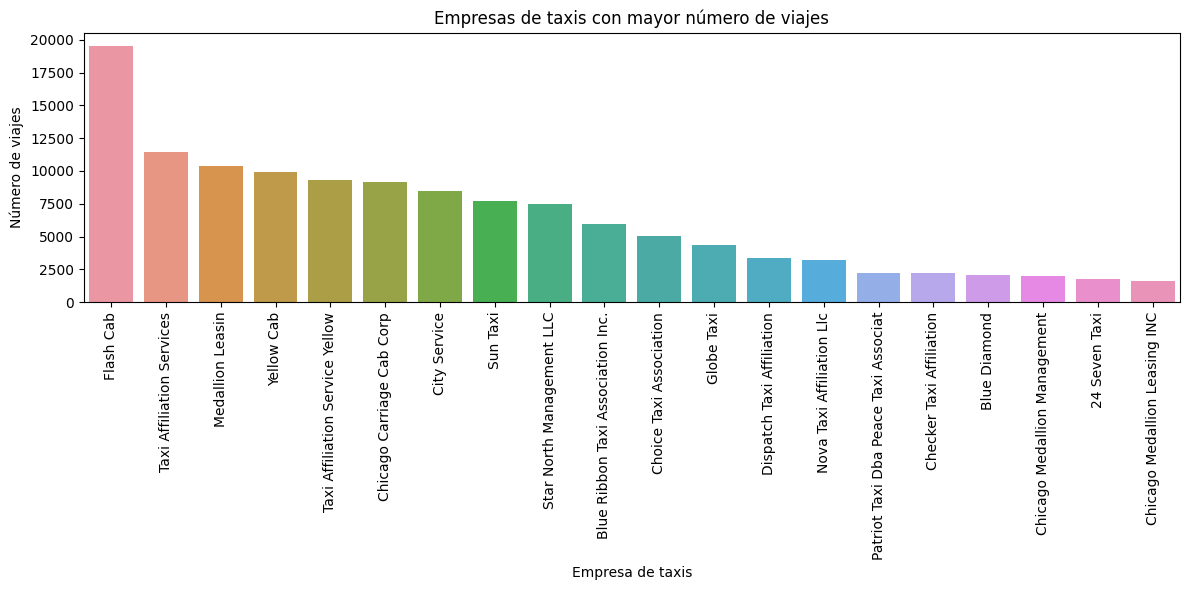

In [6]:
# Gráfico: empresas de taxis y número de viajes
plt.figure(figsize=(12,6))
sns.barplot(data=trips.sort_values('trips_amount', ascending=False).head(20), x='company_name', y='trips_amount')
plt.xticks(rotation=90)
plt.title('Empresas de taxis con mayor número de viajes')
plt.xlabel('Empresa de taxis')
plt.ylabel('Número de viajes')
plt.tight_layout()
plt.show()

**Gráfico de empresas de taxis y número de viajes:**

Las empresas líderes en número de viajes son Flash Cab, Taxi Affiliation Services y Medallion Leasin, lo que indica que tienen una mayor presencia y demanda en el mercado de taxis de Chicago durante los días analizados. La diferencia entre las primeras empresas y el resto es significativa, mostrando una concentración de viajes en pocas compañías.


**Conclusión general:**

La demanda de taxis en Chicago está concentrada tanto en ciertas empresas como en barrios específicos. Esto puede ayudar a las compañías a enfocar sus estrategias de operación y a la ciudad a entender mejor los patrones de movilidad urbana.

## Paso 5

In [7]:
# Limpieza y corrección de tipos de datos
wheather_cond.info()

# Mustra los valores duplicados y nulos
wheather_cond.drop_duplicates(inplace=True)
print(wheather_cond.duplicated().sum())
print('Valores duplicados en datos meteorológicos:')
print(wheather_cond.duplicated().sum())
print('Valores nulos en datos meteorológicos:')
print(wheather_cond.isnull().sum())

display(wheather_cond.head()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
0
Valores duplicados en datos meteorológicos:
0
Valores nulos en datos meteorológicos:
start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64


,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


## Hipótesis

**"La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos"**

Viajes en sábados lluviosos (n=148):
Duración promedio: 40.2 minutos

Viajes en sábados normales (n=723):
Duración promedio: 33.9 minutos

Resultado de la prueba t = 5.53, p = 0.0000

Conclusión: Rechazamos la hipótesis nula - hay una diferencia significativa en la duración promedio durante sábados lluviosos.


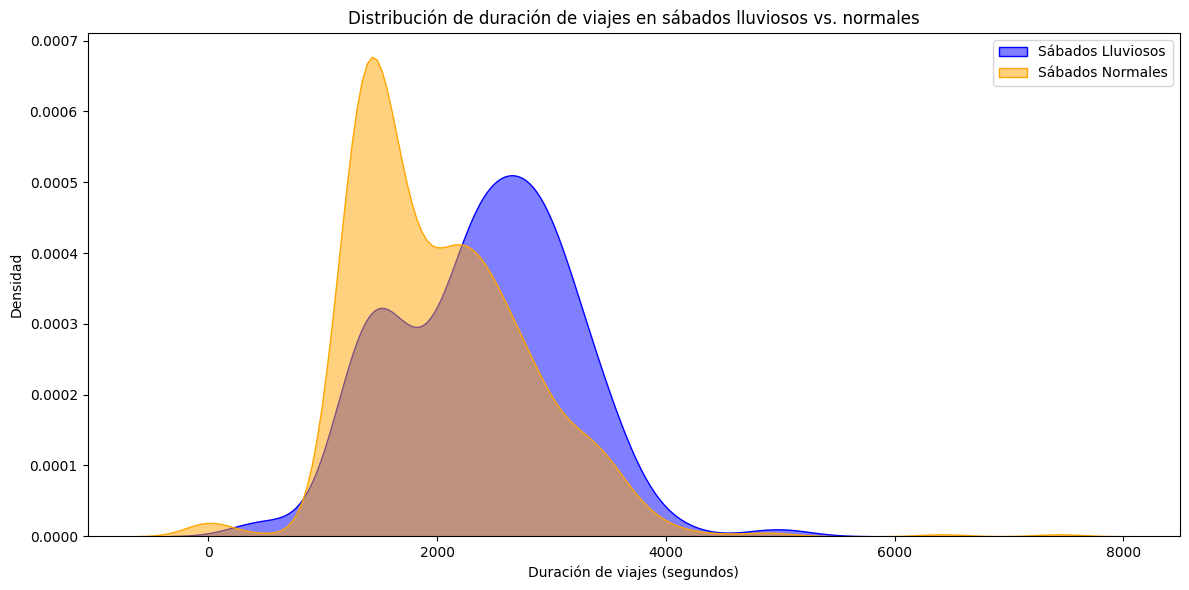

In [9]:

# prueba t para comparar la duración promedio de viajes en sábados lluviosos vs. normales

# Se enriquecen datos para análisis tomando en cuenta día de la semana y hora
wheather_cond['start_ts'] = pd.to_datetime(wheather_cond['start_ts'], errors='coerce')
wheather_cond['day_of_week'] = wheather_cond['start_ts'].dt.dayofweek  
wheather_cond['hour'] = wheather_cond['start_ts'].dt.hour

# Filtramos datos para sábados lluviosos y normales (# 5 correspondiente al sábado)
rainy_saturdays = wheather_cond[(wheather_cond['day_of_week'] == 5) & 
                               (wheather_cond['weather_conditions'] == 'Bad')]
normal_saturdays = wheather_cond[(wheather_cond['day_of_week'] == 5) & 
                                (wheather_cond['weather_conditions'] == 'Good')]

# Realizamos prueba t de dos muestras independientes
t_stat, p_value = stats.ttest_ind(rainy_saturdays['duration_seconds'], 
                                 normal_saturdays['duration_seconds'],
                                 equal_var=False)  # Usamos Welch's t-test (no asumimos varianzas iguales)

# Resultados
print(f"Viajes en sábados lluviosos (n={len(rainy_saturdays)}):")
print(f"Duración promedio: {rainy_saturdays['duration_seconds'].mean()/60:.1f} minutos")
print(f"\nViajes en sábados normales (n={len(normal_saturdays)}):")
print(f"Duración promedio: {normal_saturdays['duration_seconds'].mean()/60:.1f} minutos")
print(f"\nResultado de la prueba t = {t_stat:.2f}, p = {p_value:.4f}")

# Interpretación
alpha = 0.05
if p_value < alpha:
    print("\nConclusión: Rechazamos la hipótesis nula - hay una diferencia significativa en la duración promedio durante sábados lluviosos.")
else:
    print("\nConclusión: No podemos rechazar la hipótesis nula - no hay evidencia suficiente de diferencia en la duración promedio.")


# Gráfica de distribución de duración de viajes en sábados lluviosos vs. normales
plt.figure(figsize=(12,6))
sns.kdeplot(rainy_saturdays['duration_seconds'], label='Sábados Lluviosos', color='blue', fill=True, alpha=0.5)
sns.kdeplot(normal_saturdays['duration_seconds'], label='Sábados Normales', color='orange', fill=True, alpha=0.5)
plt.title('Distribución de duración de viajes en sábados lluviosos vs. normales')  
plt.xlabel('Duración de viajes (segundos)')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show() 

## Conclusion de la prueba

Los resultados muestran que existe evidencia estadísticamente significativa de que los viajes al Aeropuerto O'Hare desde el Loop toman más tiempo los sábados lluviosos en comparación con los sábados normales.


Duración Promedio:

    * Sábados lluviosos : 40.2 minutos

    * Sábados normales : 33.9 minutos



El mal tiempo (lluvia) aumenta significativamente el tiempo de viaje en esta ruta, lo que podría deberse a diferentes factores como accidentes, mayor congestión vehicular por condiciones adversas en la vialidad (agua estancada,baches) , obras viales o eventos especiales. 

Se utilizó una prueba t de Welch (t-test para muestras independientes con varianzas desiguales) para comprobar la hipótesis  ya que comparamos las medias de dos grupos independientes (lluvioso vs. normal).

El análisis siguió un enfoque estadístico estándar con hipótesis claras y direccionales dándonos como resultado los datos apoyan la hipótesis de que los viajes tardan más en sábados lluviosos.